In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import sklearn as sk

In [5]:
df = pd.read_csv('complaints.csv')
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-13,Mortgage,FHA mortgage,Trouble during payment process,NaN,"I currently have my mortgage with GMFS, servic...",NaN,"SAMC Honebee TRS, LLC",AL,36695,NaN,Consent provided,Web,2020-07-13,Closed with explanation,Yes,NaN,3743391
1,2023-12-16,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"FactorTrust, Inc.",NY,13224,NaN,Consent not provided,Web,2023-12-16,Closed with explanation,Yes,NaN,8011171
2,2024-01-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,11714,NaN,Consent not provided,Web,2024-01-27,Closed with non-monetary relief,Yes,NaN,8236394
3,2019-05-22,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with fraud alerts or security freezes,NaN,Have had a couple years of problems getting an...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,CA,95628,Older American,Consent provided,Web,2019-05-22,Closed with explanation,Yes,NaN,3251015
4,2023-12-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Personal information incorrect,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32703,NaN,Consent not provided,Web,2023-12-21,Closed with explanation,Yes,NaN,8032795


In [12]:
# filter df for Date received in 2014-2015 (inclusive)
if not pd.api.types.is_datetime64_any_dtype(df['Date received']):
    df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

df_2014_2015 = df[df['Date received'].dt.year.between(2014, 2015)].copy()
print(df_2014_2015.shape)
df_2014_2015.head()

(321430, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
358,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
810,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
1458,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066
1468,2015-12-18,Debt collection,"Other (i.e. phone, health club, etc.)",Communication tactics,Frequent or repeated calls,NaN,NaN,SECURITY FINANCE CORP,LA,70508,NaN,Consent not provided,Web,2015-12-21,Closed with explanation,Yes,No,1702559
1569,2015-03-04,Bank account or service,Checking account,"Making/receiving payments, sending money",NaN,NaN,NaN,WELLS FARGO & COMPANY,CT,06460,NaN,NaN,Referral,2015-03-11,Closed with explanation,Yes,No,1267075


In [13]:
# percent of disputed complaints in the filtered df_2014_2015
if df_2014_2015.empty:
    print("Filtered dataset is empty.")
else:
    # use existing mask if available, otherwise compute from column
    disputed_in_filtered = mask.loc[df_2014_2015.index].sum() if 'mask' in globals() else (df_2014_2015['Consumer disputed?'].fillna('').str.strip().str.lower() == 'yes').sum()
    pct = disputed_in_filtered / len(df_2014_2015) * 100
    print(f"Disputed: {disputed_in_filtered}/{len(df_2014_2015)} ({pct:.2f}%)")

Disputed: 63994/321430 (19.91%)


In [14]:
df_2014_2015.to_csv('complaints_training.csv', index=False)
print("Saved", df_2014_2015.shape, "to complaints_training.csv")

Saved (321430, 18) to complaints_training.csv


In [15]:
# filter for 2016 and save to complaints_test.csv
if not pd.api.types.is_datetime64_any_dtype(df['Date received']):
    df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

df_2016 = df[df['Date received'].dt.year == 2016].copy()
df_2016.to_csv('complaints_test.csv', index=False)
print("Saved", df_2016.shape, "to complaints_test.csv")

Saved (191401, 18) to complaints_test.csv


In [17]:
# filter for 2016 and save to complaints_test.csv
if not pd.api.types.is_datetime64_any_dtype(df['Date received']):
    df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

df_2017 = df[df['Date received'].dt.year == 2017].copy()
df_2017.head(100).to_csv('complaints_modeltesting100_1.csv', index=False)
print("Saved", df_2017.shape, "to complaints_test.csv")

Saved (242840, 18) to complaints_test.csv


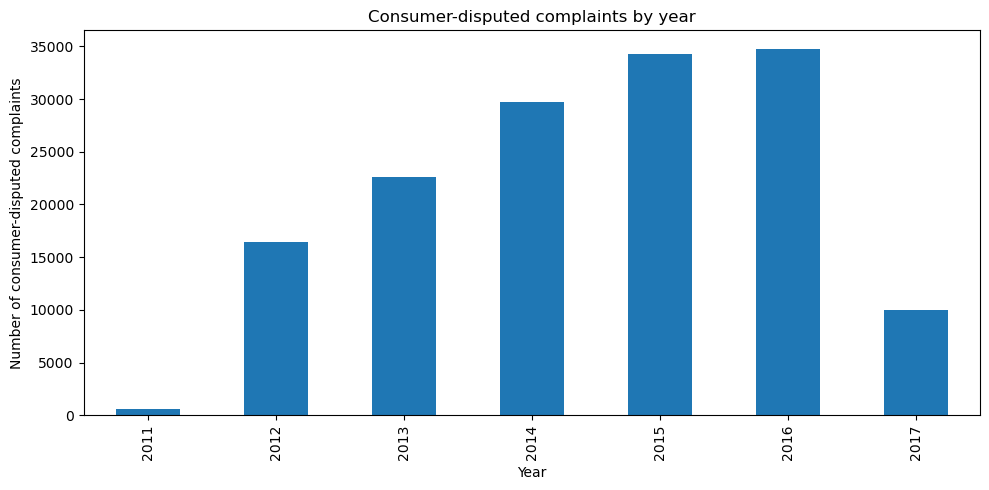

In [10]:
# histogram of consumer-disputed complaints by year
mask = df['Consumer disputed?'].fillna('').str.strip().str.lower() == 'yes'
disputed_df = df.loc[mask].copy()

if disputed_df.empty:
    print("No consumer-disputed complaints found.")
else:
    disputed_df['year'] = disputed_df['Date received'].dt.year
    counts = disputed_df['year'].value_counts().sort_index()

    plt.figure(figsize=(10, 5))
    counts.plot(kind='bar')
    plt.xlabel('Year')
    plt.ylabel('Number of consumer-disputed complaints')
    plt.title('Consumer-disputed complaints by year')
    plt.tight_layout()
    plt.show()